In [14]:
# Automation of calibrations

#import necesary modules
import h5py
import numpy as np
from scipy.optimize import curve_fit
from pyhdf.SD import SD, SDC

def gaussian(x, A, mu, sigma, offset):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset
    
# open data hdf file and select data 
file_path = "iaw.hdf"
hdf = SD(file_path, SDC.READ)
sds = hdf.select("Streak_array")
data = sds.get()

#substract the background image from the forward image 

# Handle 3D data (e.g., time, y, x)
if data.ndim == 3:
    # Find the frame with the global maximum
    frame_idx = np.argmax(np.max(data, axis=(1, 2)))
    data = data[frame_idx, :, :]

# Find coordinates of the maximum pixel
max_val = np.max(data)
y_max, x_max = np.unravel_index(np.argmax(data), data.shape)
print(y_max, x_max)

# Extract vertical lineout and flatten to 1D
lineout = data[:, x_max].flatten() 

# Create x-axis for fitting
x = np.arange(lineout.size)

# Gaussian fit setup
A_guess = np.max(lineout)
mu_guess = np.argmax(lineout)
sigma_guess = 1.0
offset_guess = np.min(lineout)
initial_guess = (A_guess, mu_guess, sigma_guess, offset_guess)

try:
    params, _ = curve_fit(gaussian, x, lineout, p0=initial_guess)
    A, mu, sigma, offset = params
    fwhm = 2.3548 * sigma
    print(f"Sigma: {sigma:.2f}, FWHM: {fwhm:.2f}, y intecept: {y_max}")
except RuntimeError as e:
    print(f"Fit failed: {e}")

384 589
Sigma: 1.86, FWHM: 4.39, y intecept: 384


In [ ]:
def calibrations_table(EPWcw,gain,CCDsize, telescope,y,X):

    #get magnifications from telescope type
    if telescope == "refractive":
        magE =1.7
        magI = 0.87
    elif telescope == "reflective":
        magE =2.3
        magI =4.5
    else: 
        raise ValueError("Telescope type must be either reflective or refractive")

    #get dispersions from central wavelenghts and gains
    epw_cws = [190,320,263,351,527]
    epw_gains = [1200,600,150]
    epw_table = [
        [{"EPWDisp": 0.05069}, {"EPWDisp": 0.1019}, {"EPWDisp": 0.4156}, {"EPWDisp": 0.4153}, {"EPWDisp": 0.4143}]]
    epw_index = epw_cws.index(EPWcw)
    epw_cali = epw_table[epw_index]
    EPWDisp = epw_cali["EPWDisp"]

    iaw_gain = [1200,3600,1800,600]
    iaw_cw = []
    iaw_table = [{("IAWDisp": 0.004, "IAW_other_value": 526)}]

    row_index_i = iaw_gains.index(cw)
    column_index_i = iaw_cws.index(gain)
    iaw_cali = iaw_table[row_index_i][column_index_i]
    IAWDisp = iaw_cali["IAWDisp"]


    row_index_e = epw_gains.index(cw)
    column_index_e = epw_cws.index(gain)
    epw_cali = epw_table[row_index_e][column_index_e]
    EPWoff = epw_cali["EPWoff"]
    EPWDisp = epw_cali["EPWDisp"]


    
    #following y = mx + b , where m the slope is the dispersion, x is the axis and y is the coordinate in the calibration picture, we want to calculate b 
    # the offsets come from b = y -mx

    IAWoff = y - IAWDisp * x 
    EPWoff = y - EPWDisp * x
    IAWoff = axisyI - axisx * IAWDisp+
    
    axisy = np.arange(1, CCDsize[0] + 1)
    axisyE = axisy * EPWDisp + EPWoff  # (nm)
    axisyI = axisy * IAWDisp + IAWoff  # (nm)
    IAWDisp = iaw_table.index(gain)

    
    axisy = np.arange(1, CCDsize[0] + 1)
    axisyE = axisy * epw_cali + EPWoff  # (nm)

    return axisyE, axisyE, axisyE, axisyE, magE, magI

CCDsize = [1024,1024]


In [13]:
#import necesary modules
import h5py
import numpy as np
from scipy.optimize import curve_fit
from pyhdf.SD import SD, SDC

def gaussian(x, A, mu, sigma, offset):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset
    
# open data hdf file and select data 
file_path = "iaw.hdf"
hdf = SD(file_path, SDC.READ)
sds = hdf.select("Streak_array")
data = sds.get()

#substract the background image from the forward image 

# Handle 3D data (e.g., time, y, x)
if data.ndim == 3:
    # Find the frame with the global maximum
    frame_idx = np.argmax(np.max(data, axis=(1, 2)))
    data = data[frame_idx, :, :]

# Find coordinates of the maximum pixel
max_val = np.max(data)
y_max, x_max = np.unravel_index(np.argmax(data), data.shape)
print(y_max, x_max)

# Extract vertical lineout and flatten to 1D
lineout = data[:, x_max].flatten() 

# Create x-axis for fitting
x = np.arange(lineout.size)

# Gaussian fit setup
A_guess = np.max(lineout)
mu_guess = np.argmax(lineout)
sigma_guess = 1.0
offset_guess = np.min(lineout)
initial_guess = (A_guess, mu_guess, sigma_guess, offset_guess)

try:
    params, _ = curve_fit(gaussian, x, lineout, p0=initial_guess)
    A, mu, sigma, offset = params
    fwhm = 2.3548 * sigma
    print(f"Sigma: {sigma:.2f}, FWHM: {fwhm:.2f}, y intecept: {y_max}")
except RuntimeError as e:
    print(f"Fit failed: {e}")

CCDsize = [1024,1024]

def calibrations_table(EPWcw,IAWcw,IAWgain,CCDsize, telescope, sigma, y_max, axisy, tstype):

    #get magnifications from telescope type
    if telescope == "refractive":
        magE =1.7
        magI = 0.87
    elif telescope == "reflective":
        magE =2.3
        magI =4.5
    else: 
        raise ValueError("Telescope type must be either reflective or refractive")

    #get dispersions from central wavelenghts and gains
    epw_cws = [190,320,263,351,527]
    epw_gains = [1200,600,150]
    epw_table = [
        [{"EPWDisp": 0.05069}, {"EPWDisp": 0.1019}, {"EPWDisp": 0.4156}, {"EPWDisp": 0.4153}, {"EPWDisp": 0.4143}]]
    epw_index = epw_cws.index(EPWcw)
    epw_cali = epw_table[epw_index]
    EPWDisp = epw_cali["EPWDisp"]

    iaw_gain = [1200,3600,1800,600]
    iaw_cw = []
    iaw_table = [{("IAWDisp": 0.004, "IAW_other_value": 526)}]

    row_index_i = iaw_gains.index(IAWcw)
    column_index_i = iaw_cws.index(IAWgain)
    iaw_cali = iaw_table[row_index_i][column_index_i]
    IAWDisp = iaw_cali["IAWDisp"]

    #stdev is sigma times the dispersion, sigma cones in pixels and we use the disppersion to convert to nm 
    stdev_EPW = sigma * EPWDisp
    stdev_IAW = sigma * IAWDisp
    
    #following y = mx + b , where m the slope is the dispersion, x is the axis and y is the coordinate in the calibration picture, we want to calculate b 
    # the offsets come from b = y -mx
    x = y_max    
    axisy = np.arange(1, CCDsize[0] + 1)
    IAWoff = axisy - IAWDisp * x 
    EPWoff = axisy - EPWDisp * x

    #calibrating the y axis
    axisyE = axisy * EPWDisp + EPWoff  # (nm)
    axisyI = axisy * IAWDisp + IAWoff  # (nm)

    #calibrating x axis based on tstype
    if tstype != "angular":
        axisx = np.arange(1, CCDsize[1] + 1)
        axisxE = axisx * magE  # ps,um
        axisxI = axisx * magI  # ps,um
        if tstype == "imaging":
            axisxE = axisxE - EPWtcc * magE
            axisxI = axisxI - IAWtcc * magI
    else:
        axisxE = np.arange(1, CCDsize[1] + 1)
        axisxI = np.arange(1, CCDsize[1] + 1)


    return axisyE, axisyI, axisxE, axisxI, magE, magI, stdev_EPW, stdev_IAW

SyntaxError: invalid syntax (292878407.py, line 75)

In [5]:
# Import necessary modules
import numpy as np
from scipy.optimize import curve_fit
from pyhdf.SD import SD, SDC

# Define Gaussian function for fitting
def gaussian(x, A, mu, sigma, offset):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset

# Data processing and analysis function
def process_and_calibrate(file_path, EPWgrating, IAWcw, IAWgain, telescope, tstype):
    # Open HDF file and read data
    hdf = SD(file_path, SDC.READ)
    try:
        sds = hdf.select("Streak_array")
        data = sds.get()
        
        # Handle 3D data (time, y, x)
        if data.ndim == 3:
            frame_idx = np.argmax(np.max(data, axis=(1, 2)))
            data = data[frame_idx, :, :]

        # Find maximum coordinates
        y_max, x_max = np.unravel_index(np.argmax(data), data.shape)
        print(f"Maximum at (y, x): ({y_max}, {x_max})")

        # Extract vertical lineout
        lineout = data[:, x_max].flatten()
        x = np.arange(lineout.size)

        # Gaussian fitting
        initial_guess = (
            np.max(lineout),
            np.argmax(lineout),
            1.0,
            np.min(lineout)
        )
        
        params, _ = curve_fit(gaussian, x, lineout, p0=initial_guess)
        A, mu, sigma, offset = params
        fwhm = 2.3548 * sigma
        print(f"Fit results - Sigma: {sigma:.2f}, FWHM: {fwhm:.2f}")

        # Calibration calculations
        CCDsize = [1024, 1024]
        cali_lw_epw =1
        cali_lw_iaw = 1
        return calibrations_table(
            EPWgrating, IAWcw, IAWgain, CCDsize, telescope,
            sigma, y_max, cali_lw_epw, cali_lw_iaw,tstype
        )

    finally:
        hdf.end()

# Calibration function with improved error handling
def calibrations_table(EPWgrating, IAWcw, IAWgain, CCDsize, telescope, sigma, mu, cali_lw_epw, cali_lw_iaw, tstype):
    # Validate inputs
    if telescope not in ["refractive", "reflective"]:
        raise ValueError("Telescope type must be 'refractive' or 'reflective'")
    
    # Telescope magnifications
    mag_values = {
        "refractive": {"magE": 1.7, "magI": 0.87},
        "reflective": {"magE": 2.3, "magI": 4.5}
    }
    magE = mag_values[telescope]["magE"]
    magI = mag_values[telescope]["magI"]

    # EPW calibration data grating and corresponding disperssions 
    epw_cali = {
        1200: 0.05069,
        600: 0.1019,
        150: 0.4151
    }
    
    # IAW calibration data
    iaw_cali = {
        (1200, 190): 0.004,
        (3600, 263): 0.005,
        (1800, 351): 0.006,
        (600, 527): 0.007
    }

    try:
        EPWDisp = epw_cali[EPWgrating]
        IAWDisp = iaw_cali[(IAWgain, IAWcw)]
    except KeyError as e:
        raise ValueError(f"Invalid calibration parameters: {e}")

    # Calculate standard deviations
    stdev_EPW = sigma * EPWDisp
    stdev_IAW = sigma * IAWDisp
    cali_lw_epw = 1
    cali_lw_iaw = 1

    if tstype == " imaging" :
            
        # Calculate offsets
        IAWoff = cali_lw_iaw - IAWDisp * mu_hor
        EPWoff = cali_lw_epw - EPWDisp * mu_hor

    else: 
        # Calculate offsets
        IAWoff = cali_lw_iaw - IAWDisp * mu_ver
        EPWoff = cali_lw_epw - EPWDisp * mu_ver
        

    # Calibrate y-axis
    axisyE = axisy * EPWDisp + EPWoff  # (nm)
    axisyI = axisy * IAWDisp + IAWoff  # (nm)

    # Calibrate x-axis
    axisx = np.arange(1, CCDsize[1] + 1)
    if tstype == "angular":
        return axisyE, axisyI, axisx, axisx, magE, magI, stdev_EPW, stdev_IAW
    
    axisxE = axisx * magE  # ps/um
    axisxI = axisx * magI  # ps/um
    
    if tstype == "imaging":
        # Add actual TCC values if available
        EPWtcc_px = mu 
        
        IAWtcc = 0  # idk what the actual tcc value is 
        axisxE -= EPWtcc * magE
        axisxI -= IAWtcc * magI

    return axisyE, axisyI, axisxE, axisxI, magE, magI, stdev_EPW, stdev_IAW

if __name__ == "__main__":
    try:
        results = process_and_calibrate(
            file_path="iaw.hdf",
            EPWgrating=150,
            IAWcw=351,
            IAWgain=1800,
            telescope="refractive",
            tstype="imaging"
        )
        print("\nCalibration results:")
        print(f"Calibrated EPW y-axis: {results[0][:5]}...")
        print(f"Calibrated IAW y-axis: {results[1][:5]}...")
    except Exception as e:
        print(f"Error in processing: {str(e)}")

Maximum at (y, x): (384, 589)
Fit results - Sigma: 1.86, FWHM: 4.39
Error in processing: name 'mu_ver' is not defined


In [7]:
# Import necessary modules
import numpy as np
from scipy.optimize import curve_fit
from pyhdf.SD import SD, SDC

# Define Gaussian function for fitting
def gaussian(x, A, mu, sigma, offset):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset

# Data processing and analysis function
def process_and_calibrate(file_path, EPWgrating, IAWcw, IAWgain, telescope, tstype):
    # Open HDF file and read data
    hdf = SD(file_path, SDC.READ)
    try:
        sds = hdf.select("Streak_array")
        data = sds.get()
        
        # Handle 3D data (time, y, x)
        if data.ndim == 3:
            frame_idx = np.argmax(np.max(data, axis=(1, 2)))
            data = data[frame_idx, :, :]

        # Find maximum coordinates
        y_max, x_max = np.unravel_index(np.argmax(data), data.shape)
        print(f"Maximum at (y, x): ({y_max}, {x_max})")

        # Extract both lineoust
        hor_lineout = data[y_max, :].flatten()
        ver_lineout = data[:, x_max].flatten()
        


        # Gaussian fitting for vertical lineout
        x_ver = np.arange(ver_lineout.size)        
        ver_initial_guess = (
            np.max(ver_lineout),
            np.argmax(ver_lineout),
            1.0,
            np.min(ver_lineout)
        )
        ver_params, _ = curve_fit(gaussian, x_ver, ver_lineout, p0=ver_initial_guess)
        ver_A, mu_ver, sigma_ver, offset_ver = ver_params
        fwhm_ver = 2.3548 * sigma_ver

        # Gaussian fitting for horizontal lineout
        x_hor = np.arange(hor_lineout.size)
        hor_initial_guess = (
            np.max(hor_lineout),
            x_max,  # Initial guess for peak position
            1.0,
            np.min(hor_lineout))
        hor_params, _ = curve_fit(gaussian, x_hor, hor_lineout, p0=hor_initial_guess)
        hor_A, mu_hor, sigma_hor, offset_hor = hor_params
        fwhm_hor = 2.3548 * sigma_hor

        print(f"\nVertical Fit Results:")
        print(f"Sigma: {sigma_ver:.2f}, FWHM: {fwhm_ver:.2f}")
        print(f"\nHorizontal Fit Results:")
        print(f"Sigma: {sigma_hor:.2f}, FWHM: {fwhm_hor:.2f}")

        # Calibration calculations
        CCDsize = [1024, 1024]
        cali_lw_epw =1
        cali_lw_iaw = 1
        return calibrations_table(
            EPWgrating, IAWcw, IAWgain, CCDsize, telescope, tstype, cali_lw_epw, cali_lw_iaw,
            mu_hor, mu_ver, sigma_hor, sigma_ver
        )

    finally:
        hdf.end()

# Calibration function with improved error handling
def calibrations_table(EPWgrating, IAWcw, IAWgain, CCDsize, telescope, tstype, cali_lw_epw, cali_lw_iaw, mu_hor, mu_ver, sigma_hor, sigma_ver):
    # Validate inputs
    if telescope not in ["refractive", "reflective"]:
        raise ValueError("Telescope type must be 'refractive' or 'reflective'")
    
    # Telescope magnifications
    mag_values = {
        "refractive": {"magE": 1.7, "magI": 0.87},
        "reflective": {"magE": 2.3, "magI": 4.5}
    }
    magE = mag_values[telescope]["magE"]
    magI = mag_values[telescope]["magI"]

    # EPW calibration data grating and corresponding disperssions 
    epw_cali = {
        1200: 0.05069,
        600: 0.1019,
        150: 0.4151
    }
    
    # IAW calibration data
    iaw_cali = {
        (1200, 190): 0.004,
        (3600, 263): 0.005,
        (1800, 351): 0.006,
        (600, 527): 0.007
    }

    try:
        EPWDisp = epw_cali[EPWgrating]
        IAWDisp = iaw_cali[(IAWgain, IAWcw)]
    except KeyError as e:
        raise ValueError(f"Invalid calibration parameters: {e}")

    cali_lw_epw = 1
    cali_lw_iaw = 1

    if tstype == " imaging" :
            
        # Calculate offsets
        IAWoff = cali_lw_iaw - IAWDisp * mu_hor
        EPWoff = cali_lw_epw - EPWDisp * mu_hor
        # Calculate standard deviations
        stdev_EPW = sigma_hor * EPWDisp
        stdev_IAW = sigma_hor * IAWDisp

    else: 
        # Calculate offsets
        IAWoff = cali_lw_iaw - IAWDisp * mu_ver
        EPWoff = cali_lw_epw - EPWDisp * mu_ver
        # Calculate standard deviations
        stdev_EPW = sigma_ver * EPWDisp
        stdev_IAW = sigma_ver * IAWDisp
        

    # Calibrate y-axis
    axisy = np.arange(1, CCDsize[0] + 1)
    axisyE = axisy * EPWDisp + EPWoff  # (nm)
    axisyI = axisy * IAWDisp + IAWoff  # (nm)

    # Calibrate x-axis
    axisx = np.arange(1, CCDsize[1] + 1)
    if tstype == "angular":
        return axisyE, axisyI, axisx, axisx, magE, magI, stdev_EPW, stdev_IAW
    
    axisxE = axisx * magE  # ps/um
    axisxI = axisx * magI  # ps/um
    
    if tstype == "imaging":
        # Add actual TCC values if available
        EPWtcc_px = mu 
        
        IAWtcc = 0  # idk what the actual tcc value is 
        axisxE -= EPWtcc * magE
        axisxI -= IAWtcc * magI

    return axisyE, axisyI, axisxE, axisxI, magE, magI, stdev_EPW, stdev_IAW

if __name__ == "__main__":
    try:
        results = process_and_calibrate(
            file_path="iaw.hdf",
            EPWgrating=150,
            IAWcw=351,
            IAWgain=1800,
            telescope="refractive",
            tstype="imaging"
        )
        print("\nCalibration results:")
        print(f"Calibrated EPW y-axis: {results[0][:5]}...")
        print(f"Calibrated IAW y-axis: {results[1][:5]}...")
    except Exception as e:
        print(f"Error in processing: {str(e)}")

Maximum at (y, x): (384, 589)

Vertical Fit Results:
Sigma: 1.86, FWHM: 4.39

Horizontal Fit Results:
Sigma: 1.55, FWHM: 3.66
Error in processing: name 'mu' is not defined


In [1]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Maximum at (y, x): (384, 589)


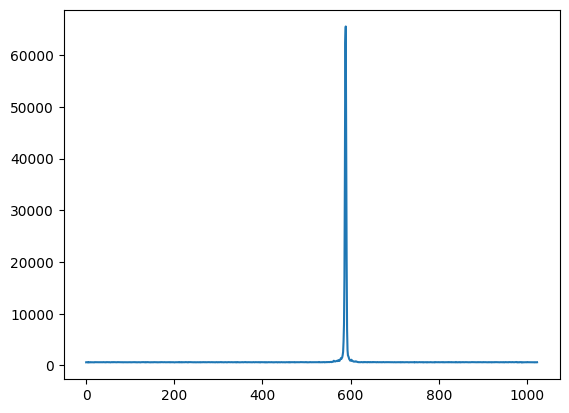

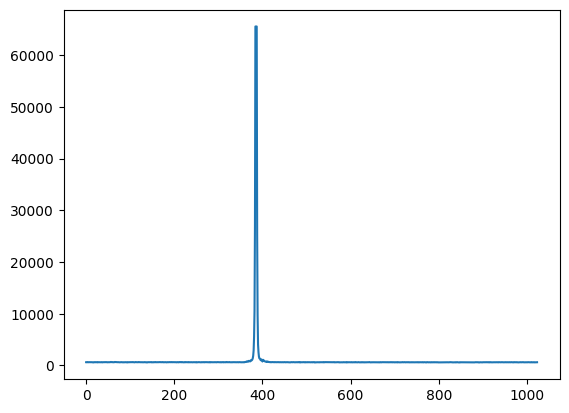


Vertical Fit Results:
Sigma: 1.86, FWHM: 4.39

Horizontal Fit Results:
Sigma: 1.55, FWHM: 3.66

Calibration results:
(0.4151, 0.006, -159.01246604968225, -1.3128759245918897, 1.7, 0.87, 0.7735584512946037, 0.011181283323940307)


In [3]:
# Import necessary modules
import numpy as np
from scipy.optimize import curve_fit
from pyhdf.SD import SD, SDC
from matplotlib import pyplot as plt

# Define Gaussian function for fitting
def gaussian(x, A, mu, sigma, offset):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset

# Data processing and analysis function
def process_and_calibrate(file_path, EPWgrating, IAWcw, IAWgain, telescope, tstype):
    # Open HDF file and read data
    hdf = SD(file_path, SDC.READ)
    try:
        sds = hdf.select("Streak_array")
        data = sds.get()
        
        # Handle 3D data (time, y, x)
        if data.ndim == 3:
            frame_idx = np.argmax(np.max(data, axis=(1, 2)))
            data = data[frame_idx, :, :]

        # Find maximum coordinates
        y_max, x_max = np.unravel_index(np.argmax(data), data.shape)
        print(f"Maximum at (y, x): ({y_max}, {x_max})")

        # Extract both lineoust
        hor_lineout = data[y_max, :].flatten()
        ver_lineout = data[:, x_max].flatten()

        plt.plot(hor_lineout)
        plt.show()

        plt.plot(ver_lineout)
        plt.show()

        

        # Gaussian fitting for vertical lineout
        x_ver = np.arange(ver_lineout.size)        
        ver_initial_guess = (
            np.max(ver_lineout),
            np.argmax(ver_lineout),
            1.0,
            np.min(ver_lineout)
        )
        ver_params, _ = curve_fit(gaussian, x_ver, ver_lineout, p0=ver_initial_guess)
        ver_A, mu_ver, sigma_ver, offset_ver = ver_params
        fwhm_ver = 2.3548 * sigma_ver

        # Gaussian fitting for horizontal lineout
        x_hor = np.arange(hor_lineout.size)
        hor_initial_guess = (
            np.max(hor_lineout),
            x_max,  # Initial guess for peak position
            1.0,
            np.min(hor_lineout))
        hor_params, _ = curve_fit(gaussian, x_hor, hor_lineout, p0=hor_initial_guess)
        hor_A, mu_hor, sigma_hor, offset_hor = hor_params
        fwhm_hor = 2.3548 * sigma_hor

        print(f"\nVertical Fit Results:")
        print(f"Sigma: {sigma_ver:.2f}, FWHM: {fwhm_ver:.2f}")
        print(f"\nHorizontal Fit Results:")
        print(f"Sigma: {sigma_hor:.2f}, FWHM: {fwhm_hor:.2f}")

        # Calibration calculations
        CCDsize = [1024, 1024]
        cali_lw_epw =1
        cali_lw_iaw = 1
        return calibrations_table(
            EPWgrating, IAWcw, IAWgain, CCDsize, telescope, tstype, cali_lw_epw, cali_lw_iaw,
            mu_hor, mu_ver, sigma_hor, sigma_ver
        )

    finally:
        hdf.end()

# Calibration function with improved error handling
def calibrations_table(EPWgrating, IAWcw, IAWgain, CCDsize, telescope, tstype, cali_lw_epw, cali_lw_iaw, mu_hor, mu_ver, sigma_hor, sigma_ver):
    # Validate inputs
    if telescope not in ["refractive", "reflective"]:
        raise ValueError("Telescope type must be 'refractive' or 'reflective'")
    
    # Telescope magnifications
    mag_values = {
        "refractive": {"magE": 1.7, "magI": 0.87},
        "reflective": {"magE": 2.3, "magI": 4.5}
    }
    magE = mag_values[telescope]["magE"]
    magI = mag_values[telescope]["magI"]

    # EPW calibration data grating and corresponding disperssions 
    epw_cali = {
        1200: 0.05069,
        600: 0.1019,
        150: 0.4151
    }
    
    # IAW calibration data
    iaw_cali = {
        (1200, 190): 0.004,
        (3600, 263): 0.005,
        (1800, 351): 0.006,
        (600, 527): 0.007
    }

    try:
        EPWDisp = epw_cali[EPWgrating]
        IAWDisp = iaw_cali[(IAWgain, IAWcw)]
    except KeyError as e:
        raise ValueError(f"Invalid calibration parameters: {e}")

    cali_lw_epw = 1
    cali_lw_iaw = 1

    if tstype == " imaging" :
            
        # Calculate offsets
        IAWoff = cali_lw_iaw - IAWDisp * mu_hor
        EPWoff = cali_lw_epw - EPWDisp * mu_hor
        # Calculate standard deviations
        stdev_EPW = sigma_hor * EPWDisp
        stdev_IAW = sigma_hor * IAWDisp

    else: 
        # Calculate offsets
        IAWoff = cali_lw_iaw - IAWDisp * mu_ver
        EPWoff = cali_lw_epw - EPWDisp * mu_ver
        # Calculate standard deviations
        stdev_EPW = sigma_ver * EPWDisp
        stdev_IAW = sigma_ver * IAWDisp
        

    return  EPWDisp, IAWDisp, EPWoff, IAWoff, magE, magI, stdev_EPW, stdev_IAW

if __name__ == "__main__":
    try:
        results = process_and_calibrate(
            file_path="iaw.hdf",
            EPWgrating=150,
            IAWcw=351,
            IAWgain=1800,
            telescope="refractive",
            tstype="imaging"
        )
        print("\nCalibration results:")
        print(results)
        #print(f"Calibrated EPW y-axis: {results[0][:5]}...")
       # print(f"Calibrated IAW y-axis: {results[1][:5]}...")
    except Exception as e:
        print(f"Error in processing: {str(e)}")

(2, 1024, 1024)
(1024, 1024)


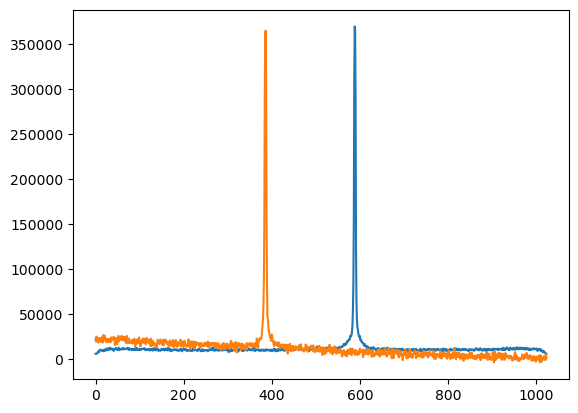

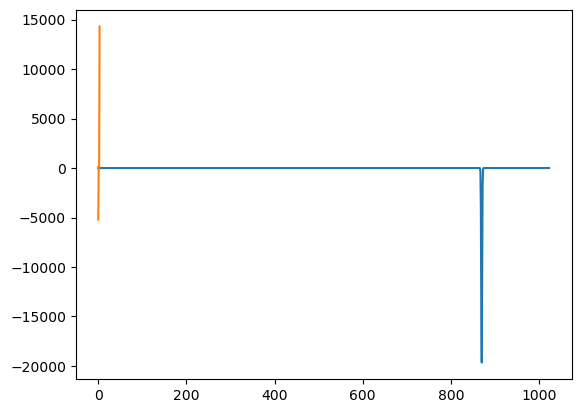


Vertical Fit Results:
Sigma: 233.48, FWHM: 549.80

Horizontal Fit Results:
Sigma: -139.35, FWHM: -328.15
233.48199890797193

Calibration results:
(0.4151, 0.007, -360.0551699477752, -5.088620066572937, 1.7, 0.87, 96.91837774669915, 1.6343739923558036)


In [12]:
# Import necessary modules
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from pyhdf.SD import SD, SDC

# Define Gaussian function for fitting
def gaussian(x, A, mu, sigma, offset):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset

# Data processing and analysis function
def process_and_calibrate(file_path, EPWgrating, IAWcw, IAWgain, telescope, tstype):
    # Open HDF file and read data
    hdf = SD(file_path, SDC.READ)
    try:
        sds = hdf.select("Streak_array")
        data = sds.get()
        
        # Handle 3D data (time, y, x)
        if data.ndim == 3:
            frame_idx = np.argmax(np.max(data, axis=(1, 2)))
            #data = data[frame_idx, :, :]
            print(data.shape)
            data = data.astype(float)
            data = np.squeeze(data[0,:,:] - data[1,:,:])
        print(data.shape)
        # Find maximum coordinates
        ver_lineout = np.sum(data, axis = 1)
        hor_lineout = np.sum(data, axis = 0)
        # plt.plot(hor_sum)
        # plt.show()
        # plt.plot(ver_sum)
        # # plt.show()
        # y_max, x_max = np.unravel_index(np.argmax(data), data.shape)
        # print(f"Maximum at (y, x): ({y_max}, {x_max})")

        # plt.imshow(data)
        # plt.show()
        # # Extract both lineoust
        # #hor_lineout = data[y_max, :].flatten()
        # # ver_lineout = data[:, x_max].flatten()
        plt.plot(hor_lineout)
        plt.plot(ver_lineout)
        plt.show()


        # Gaussian fitting for vertical lineout
        x_ver = np.arange(ver_lineout.size)        
        ver_initial_guess = (
            np.max(ver_lineout),
            512,
            1.0,
            np.min(ver_lineout)
        )
        ver_params, _ = curve_fit(gaussian, x_ver, ver_lineout, p0=ver_initial_guess)
        ver_A, mu_ver, sigma_ver, offset_ver = ver_params
        
        fit_A = ver_params[0]
        fit_B = ver_params[1]

        fit_y = gaussian(x_ver, fit_A,fit_B,1,1)
        plt.plot(x_ver, fit_y)
        fwhm_ver = 2.3548 * sigma_ver

        # Gaussian fitting for horizontal lineout
        x_hor = np.arange(hor_lineout.size)
        hor_initial_guess = (
            np.max(hor_lineout),
            512,  # Initial guess for peak position
            1.0,
            np.min(hor_lineout))
        hor_params, _ = curve_fit(gaussian, x_hor, hor_lineout, p0=hor_initial_guess)
        hor_A, mu_hor, sigma_hor, offset_hor = hor_params
        plt.plot(hor_params)
        plt.show()
        fwhm_hor = 2.3548 * sigma_hor

        print(f"\nVertical Fit Results:")
        print(f"Sigma: {sigma_ver:.2f}, FWHM: {fwhm_ver:.2f}")
        print(f"\nHorizontal Fit Results:")
        print(f"Sigma: {sigma_hor:.2f}, FWHM: {fwhm_hor:.2f}")

        # Calibration calculations
        CCDsize = [1024, 1024]
        cali_lw_epw =1
        cali_lw_iaw = 1

        print(sigma_ver)
        return calibrations_table(
            EPWgrating, IAWcw, IAWgain, CCDsize, telescope, tstype, cali_lw_epw, cali_lw_iaw,
            mu_hor, mu_ver, sigma_hor, sigma_ver
        )

    finally:
        hdf.end()

# Calibration function with improved error handling
def calibrations_table(EPWgrating, IAWcw, IAWgain, CCDsize, telescope, tstype, cali_lw_epw, cali_lw_iaw, mu_hor, mu_ver, sigma_hor, sigma_ver):
    # Validate inputs
    if telescope not in ["refractive", "reflective"]:
        raise ValueError("Telescope type must be 'refractive' or 'reflective'")
    
    # Telescope magnifications
    mag_values = {
        "refractive": {"magE": 1.7, "magI": 0.87},
        "reflective": {"magE": 2.3, "magI": 4.5}
    }
    magE = mag_values[telescope]["magE"]
    magI = mag_values[telescope]["magI"]

    # EPW calibration data grating and corresponding disperssions 
    epw_cali = {
        1200: 0.05069,
        600: 0.1019,
        150: 0.4151
    }
    
    # IAW calibration data
    iaw_cali = {
        (1200, 190): 0.004,
        (3600, 263): 0.005,
        (1800, 351): 0.006,
        (600, 527): 0.007
    }

    try:
        EPWDisp = epw_cali[EPWgrating]
        IAWDisp = iaw_cali[(IAWgain, IAWcw)]
    except KeyError as e:
        raise ValueError(f"Invalid calibration parameters: {e}")

    cali_lw_epw = 1
    cali_lw_iaw = 1

    if tstype == " imaging" :
            
        # Calculate offsets
        IAWoff = cali_lw_iaw - IAWDisp * mu_hor
        EPWoff = cali_lw_epw - EPWDisp * mu_hor
        # Calculate standard deviations
        stdev_EPW = sigma_hor * EPWDisp
        stdev_IAW = sigma_hor * IAWDisp

    else: 
        # Calculate offsets
        IAWoff = cali_lw_iaw - IAWDisp * mu_ver
        EPWoff = cali_lw_epw - EPWDisp * mu_ver
        # Calculate standard deviations
        stdev_EPW = sigma_ver * EPWDisp
        stdev_IAW = sigma_ver * IAWDisp
        

    return  EPWDisp, IAWDisp, EPWoff, IAWoff, magE, magI, stdev_EPW, stdev_IAW

if __name__ == "__main__":
    try:
        results = process_and_calibrate(
            file_path="iaw.hdf",
            EPWgrating=150,
            IAWcw=527,
            IAWgain=600,
            telescope="refractive",
            tstype="spectral"
        )
        print("\nCalibration results:")
        print(results)
        #print(f"Calibrated EPW y-axis: {results[0][:5]}...")
       # print(f"Calibrated IAW y-axis: {results[1][:5]}...")
    except Exception as e:
        print(f"Error in processing: {str(e)}")

In [7]:
pip install pandas openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
from datetime import datetime

#Save results on excel file 
def save_to_excel(results, filename=None):
    """
    Save calibration results to Excel file with timestamp
    Returns: Output filename
    """
    # Unpack results
    #axisyE, axisyI, axisxE, axisxI, magE, magI, stdev_EPW, stdev_IAW = results
    EPWDisp, IAWDisp, EPWoff, IAWoff, magE, magI, stdev_EPW, stdev_IAW = results
    
    # Create DataFrames
    summary_data = {
        "Parameter": ["Dispersion EPW", "Dispersion IAW","Offset EPW" , "Offset IAW"
                    ,"Magnification EPW", "Magnification IAW", "EPW Standard Deviation (nm)", "IAW Standard Deviation (nm)"],
        "Value": [EPWDisp, IAWDisp, EPWoff, IAWoff, magE, magI, stdev_EPW, stdev_IAW]
    }
    df_summary = pd.DataFrame(summary_data)


    # Create filename with timestamp
    if not filename:
        timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        filename = f"Calibration_{timestamp}.xlsx"

    # Write to Excel
    with pd.ExcelWriter(filename) as writer:
        df_summary.to_excel(writer, sheet_name="Summary", index=False)
        
    return filename


if __name__ == "__main__":
    try:
        results = process_and_calibrate(
            file_path="iaw.hdf",
            EPWgrating=150,
            IAWcw=351,
            IAWgain=1800,
            telescope="refractive",
            tstype="imaging"
        )
        
        # Save to Excel
        output_file = save_to_excel(results)
        print(f"\nResults saved to: {output_file}")
        
    except Exception as e:
        print(f"Error in processing: {str(e)}")

Error in processing: name 'process_and_calibrate' is not defined


In [25]:
import pandas as pd
from datetime import datetime

def save_to_excel(results, file_path, filename="calibration_results.xlsx"):
    """
    Save calibration results to Excel file organized by analysis date
    """
    # Get file creation date from the analyzed HDF file
    creation_time = os.path.getctime(file_path)
    analysis_date = datetime.fromtimestamp(creation_time).date()
    
    # Define consistent column order and structure
    columns = [
        'Analysis Date', 'Dispersion EPW', 'Dispersion IAW',
        'Offset EPW', 'Offset IAW', 'Magnification EPW',
        'Magnification IAW', 'EPW Std Dev (nm)', 'IAW Std Dev (nm)'
    ]
    
    # Create new results DataFrame with explicit columns
    new_data = pd.DataFrame([{
        'Analysis Date': analysis_date,
        'Dispersion EPW': results[0],
        'Dispersion IAW': results[1],
        'Offset EPW': results[2],
        'Offset IAW': results[3],
        'Magnification EPW': results[4],
        'Magnification IAW': results[5],
        'EPW Std Dev (nm)': results[6],
        'IAW Std Dev (nm)': results[7]
    }], columns=columns)

    try:
        # Try reading existing file with consistent columns
        df = pd.read_excel(filename, parse_dates=['Analysis Date'])
        df['Analysis Date'] = df['Analysis Date'].dt.date
        
        # Ensure existing DF has all columns
        df = df.reindex(columns=columns, fill_value=np.nan)
    except FileNotFoundError:
        # Create empty DF with correct columns if file doesn't exist
        df = pd.DataFrame(columns=columns)

    # Remove existing entries for this date
    mask = df['Analysis Date'] != analysis_date
    updated_df = pd.concat([df[mask], new_data], ignore_index=True)

    # Sort and format dates
    updated_df = updated_df.sort_values('Analysis Date')
    updated_df['Analysis Date'] = updated_df['Analysis Date'].astype(str)

    # Save to Excel
    with pd.ExcelWriter(filename, engine='openpyxl', mode='w') as writer:
        updated_df.to_excel(writer, index=False)
    
    return filename

In [20]:
import pandas as pd
from datetime import datetime

#Save results on excel file 
def save_to_excel(results, filename=None):
    """
    Save calibration results to Excel file with timestamp
    Returns: Output filename
    """
    # Unpack results
    #axisyE, axisyI, axisxE, axisxI, magE, magI, stdev_EPW, stdev_IAW = results
    EPWDisp, IAWDisp, EPWoff, IAWoff, magE, magI, stdev_EPW, stdev_IAW = results
    
    # Create DataFrames
    summary_data = {
        "Parameter": ["Dispersion EPW", "Dispersion IAW","Offset EPW" , "Offset IAW"
                    ,"Magnification EPW", "Magnification IAW", "EPW Standard Deviation (nm)", "IAW Standard Deviation (nm)"],
        "Value": [EPWDisp, IAWDisp, EPWoff, IAWoff, magE, magI, stdev_EPW, stdev_IAW]
    }
    df_summary = pd.DataFrame(summary_data)
    
    # Create axis DataFrames
    df_epw = pd.DataFrame({
        "X-axis (um/ps)": axisxE,
        "Y-axis (nm)": axisyE
    })
    
    df_iaw = pd.DataFrame({
        "X-axis (um/ps)": axisxI,
        "Y-axis (nm)": axisyI
    })

    # Create filename with timestamp
    if not filename:
        timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        filename = f"Calibration_{timestamp}.xlsx"

    # Write to Excel
    with pd.ExcelWriter(filename) as writer:
        df_summary.to_excel(writer, sheet_name="Summary", index=False)
        df_epw.to_excel(writer, sheet_name="EPW_Axes", index=False)
        df_iaw.to_excel(writer, sheet_name="IAW_Axes", index=False)
        
    return filename


if __name__ == "__main__":
    try:
        results = process_and_calibrate(
            file_path="iaw.hdf",
            EPWgrating=150,
            IAWcw=351,
            IAWgain=1800,
            telescope="refractive",
            tstype="imaging"
        )
        
        # Save to Excel
        output_file = save_to_excel(results)
        print(f"\nResults saved to: {output_file}")
        
    except Exception as e:
        print(f"Error in processing: {str(e)}")

Maximum at (y, x): (384, 589)

Vertical Fit Results:
Sigma: 1.86, FWHM: 4.39

Horizontal Fit Results:
Sigma: 1.55, FWHM: 3.66
Error in processing: name 'axisxE' is not defined


In [4]:
# Calibrations but not axis calibrations


# Import necessary modules
import numpy as np
from scipy.optimize import curve_fit
from pyhdf.SD import SD, SDC

# Define Gaussian function for fitting
def gaussian(x, A, mu, sigma, offset):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset

# Data processing and analysis function
def process_and_calibrate(file_path, EPWgrating, IAWcw, IAWgain, telescope, tstype):
    # Open HDF file and read data
    hdf = SD(file_path, SDC.READ)
    try:
        sds = hdf.select("Streak_array")
        data = sds.get()
        
        # Handle 3D data (time, y, x)
        if data.ndim == 3:
            frame_idx = np.argmax(np.max(data, axis=(1, 2)))
            data = data[frame_idx, :, :]

        # Find maximum coordinates
        y_max, x_max = np.unravel_index(np.argmax(data), data.shape)
        print(f"Maximum at (y, x): ({y_max}, {x_max})")

        # Extract both lineoust
        hor_lineout = data[y_max, :].flatten()
        ver_lineout = data[:, x_max].flatten()
        

        # Gaussian fitting for vertical lineout
        x_ver = np.arange(ver_lineout.size)        
        ver_initial_guess = (
            np.max(ver_lineout),
            np.argmax(ver_lineout),
            1.0,
            np.min(ver_lineout)
        )
        ver_params, _ = curve_fit(gaussian, x_ver, ver_lineout, p0=ver_initial_guess)
        ver_A, mu_ver, sigma_ver, offset_ver = ver_params
        fwhm_ver = 2.3548 * sigma_ver

        # Gaussian fitting for horizontal lineout
        x_hor = np.arange(hor_lineout.size)
        hor_initial_guess = (
            np.max(hor_lineout),
            x_max,  # Initial guess for peak position
            1.0,
            np.min(hor_lineout))
        hor_params, _ = curve_fit(gaussian, x_hor, hor_lineout, p0=hor_initial_guess)
        hor_A, mu_hor, sigma_hor, offset_hor = hor_params
        fwhm_hor = 2.3548 * sigma_hor

        print(f"\nVertical Fit Results:")
        print(f"Sigma: {sigma_ver:.2f}, FWHM: {fwhm_ver:.2f}")
        print(f"\nHorizontal Fit Results:")
        print(f"Sigma: {sigma_hor:.2f}, FWHM: {fwhm_hor:.2f}")

        # Calibration calculations
        CCDsize = [1024, 1024]
        cali_lw_epw =1
        cali_lw_iaw = 1
        return calibrations_table(
            EPWgrating, IAWcw, IAWgain, CCDsize, telescope, tstype, cali_lw_epw, cali_lw_iaw,
            mu_hor, mu_ver, sigma_hor, sigma_ver
        )

    finally:
        hdf.end()

# Calibration function with improved error handling
def calibrations_table(EPWgrating, IAWcw, IAWgain, CCDsize, telescope, tstype, cali_lw_epw, cali_lw_iaw, mu_hor, mu_ver, sigma_hor, sigma_ver):
    # Validate inputs
    if telescope not in ["refractive", "reflective"]:
        raise ValueError("Telescope type must be 'refractive' or 'reflective'")
    
    # Telescope magnifications
    mag_values = {
        "refractive": {"magE": 1.7, "magI": 0.87},
        "reflective": {"magE": 2.3, "magI": 4.5}
    }
    magE = mag_values[telescope]["magE"]
    magI = mag_values[telescope]["magI"]

    # EPW calibration data grating and corresponding disperssions 
    epw_cali = {
        1200: 0.05069,
        600: 0.1019,
        150: 0.4151
    }
    
    # IAW calibration data
    iaw_cali = {
        (1200, 190): 0.004,
        (3600, 263): 0.005,
        (1800, 351): 0.006,
        (600, 527): 0.007
    }

    try:
        EPWDisp = epw_cali[EPWgrating]
        IAWDisp = iaw_cali[(IAWgain, IAWcw)]
    except KeyError as e:
        raise ValueError(f"Invalid calibration parameters: {e}")

    cali_lw_epw = 1
    cali_lw_iaw = 1

    if tstype == " imaging" :
            
        # Calculate offsets
        IAWoff = cali_lw_iaw - IAWDisp * mu_hor
        EPWoff = cali_lw_epw - EPWDisp * mu_hor
        # Calculate standard deviations
        stdev_EPW = sigma_hor * EPWDisp
        stdev_IAW = sigma_hor * IAWDisp

    else: 
        # Calculate offsets
        IAWoff = cali_lw_iaw - IAWDisp * mu_ver
        EPWoff = cali_lw_epw - EPWDisp * mu_ver
        # Calculate standard deviations
        stdev_EPW = sigma_ver * EPWDisp
        stdev_IAW = sigma_ver * IAWDisp


    return   EPWoff, IAWoff, stdev_EPW, stdev_IAW, magE, magI

if __name__ == "__main__":
    try:
        results = process_and_calibrate(
            file_path="iaw.hdf",
            EPWgrating=150,
            IAWcw=351,
            IAWgain=1800,
            telescope="refractive",
            tstype="imaging"
        )
        print("\nCalibration results:")
        print(f"Calibrated EPW y-axis: {results[0][:5]}...")
        print(f"Calibrated IAW y-axis: {results[1][:5]}...")
    except Exception as e:
        print(f"Error in processing: {str(e)}")

Maximum at (y, x): (384, 589)

Vertical Fit Results:
Sigma: 1.86, FWHM: 4.39

Horizontal Fit Results:
Sigma: 1.55, FWHM: 3.66

Calibration results:
Error in processing: invalid index to scalar variable.


In [ ]:
# Import necessary modules
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from pyhdf.SD import SD, SDC

# Define Gaussian function for fitting
def gaussian(x, A, mu, sigma, offset):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset

# Data processing and analysis function
def process_and_calibrate(file_path, date, EPWgrating, EPWcw, IAWcw, IAWgrating, telescope, tstype):
    # Open HDF file and read data
    hdf = SD(file_path, SDC.READ)
    try:
        sds = hdf.select("Streak_array")
        data = sds.get()
        
        # Handle 3D data (time, y, x)
        if data.ndim == 3:
            frame_idx = np.argmax(np.max(data, axis=(1, 2)))
            #data = data[frame_idx, :, :]
            print(data.shape)
            data = data.astype(float)
            data = np.squeeze(data[0,:,:] - data[1,:,:])
        print(data.shape)
        #separate analysis by type 
        if tstype == "temporal":
            
            # Find maximum coordinates
            ver_lineout = np.sum(data, axis = 1)
            plt.plot(ver_lineout)
            plt.show()
            
            # Gaussian fitting for vertical lineout
            x_ver = np.arange(ver_lineout.size)        
            ver_initial_guess = (
                np.max(ver_lineout),
                512, # Initial guess for peak position
                1.0,
                np.min(ver_lineout)
            )
            ver_params, _ = curve_fit(gaussian, x_ver, ver_lineout, p0=ver_initial_guess)
            ver_A, mu_ver, sigma_ver, offset_ver = ver_params
            
            fit_A = ver_params[0]
            fit_B = ver_params[1]
    
            fit_y = gaussian(x_ver, fit_A,fit_B,1,1)
            plt.plot(x_ver, fit_y)
            fwhm_ver = 2.3548 * sigma_ver
            mu_hor, sigma_hor = 0
            print(f"\nVertical Fit Results:")
            print(f"Sigma: {sigma_ver:.2f}, FWHM: {fwhm_ver:.2f}")
            

        elif tstype == "imaging":
            #same analysis as above but now for ccd
            hor_lineout = np.sum(data, axis = 0)
            plt.plot(hor_lineout)
            plt.show()
    
            # Gaussian fitting for horizontal lineout
            x_hor = np.arange(hor_lineout.size)
            hor_initial_guess = (
                np.max(hor_lineout),
                512, 
                1.0,
                np.min(hor_lineout)
            )
            hor_params, _ = curve_fit(gaussian, x_hor, hor_lineout, p0=hor_initial_guess)
            hor_A, mu_hor, sigma_hor, offset_hor = hor_params
            plt.plot(hor_params)
            plt.show()
            fwhm_hor = 2.3548 * sigma_hor            
            mu_ver, sigma_ver = 0

            print(f"\nHorizontal Fit Results:")
            print(f"Sigma: {sigma_hor:.2f}, FWHM: {fwhm_hor:.2f}")
            

        # Calibration calculations
        CCDsize = [1024, 1024]
        cali_lw_epw =1
        cali_lw_iaw = 1

        return calibrations_table(
            EPWgrating, EPWcw, IAWcw, IAWgrating, CCDsize, telescope, tstype, cali_lw_epw, cali_lw_iaw,
            mu_hor, mu_ver, sigma_hor, sigma_ver
        )

    finally:
        hdf.end()

# Calibration function with improved error handling
def calibrations_table(EPWgrating, EPWcw, IAWcw, IAWgrating, CCDsize, telescope, tstype, cali_lw_epw, cali_lw_iaw, mu_hor, mu_ver, sigma_hor, sigma_ver):
    # Validate inputs
    if telescope not in ["refractive", "reflective"]:
        raise ValueError("Telescope type must be 'refractive' or 'reflective'")
    
    # Telescope magnifications
    mag_values = {
        "refractive": {"magE": 1.7, "magI": 0.87},
        "reflective": {"magE": 2.3, "magI": 4.5}
    }
    magE = mag_values[telescope]["magE"]
    magI = mag_values[telescope]["magI"]

  
    cali_lw_epw = 1
    cali_lw_iaw = 1

    if tstype == " temporal" :
        # calibration data grating cw and corresponding disperssions 
        #IAW ROSS
        iaw_cali = {
            (1800, 365): 0.00984,
            (1800, 366): 0.00986,
            (1800, 520): 0.00902,
            (1800, 524): 0.00902,
            (2160, 522): 0.00686,
            (2160, 525): 0.00683,
            (2400, 351): 0.00711,
            (2400, 520): 0.00575,
            (2400, 522): 0.00571,
            (3600, 264): 0.00446,
            (3600, 265): 0.00449,
            (3600, 351): 0.00378  }
        #EPW ROSS
        epw_cali = {
            (150, 263) : 0.4156,
            (150, 351) : 0.4153,
            (150, 527) : 0.4153,
            (600, 320) : 0.1019,
            (1200, 190) : 0.05069,
            (1200, 180) : 0.05026    }
        try:
            EPWDisp = epw_cali[(EPWgrating, EPWcw)]
            IAWDisp = iaw_cali[(IAWgrating, IAWcw)]
        except KeyError as e:
            raise ValueError(f"Invalid calibration parameters: {e}")
        # Calculate offsets
        IAWoff = cali_lw_iaw - IAWDisp * mu_ver
        EPWoff = cali_lw_epw - EPWDisp * mu_ver
        # Calculate standard deviations
        stdev_EPW = sigma_ver * EPWDisp
        stdev_IAW = sigma_ver * IAWDisp
            

    else: # tstype is imaging
        #EPW CCD
        epw_cali = {
            (150, 260) : 0.274,
            (150, 351) : 0.275,
            (150, 527) : 0.277,
            (600, 320) : 0.0678,
            (600, 685) : 0.0669,
            (1200, 180) : 0.0331  }
    
        
        # IAW CCD calib): ration data
        iaw_cali = {
            (1800, 701): 0.00482,
            (1800, 707): 0.00481,
            (2160, 522): 0.00437,
            (2160, 525): 0.00448,
            (2400, 351): 0.00446,
            (2400, 520): 0.00368,
            (2400, 522): 0.00365,
            (3600, 264): 0.00286,
            (3600, 265): 0.00284

        }
        try:
            EPWDisp = epw_cali[(EPWgrating, EPWcw)]
            IAWDisp = iaw_cali[(IAWgrating, IAWcw)]
        except KeyError as e:
            raise ValueError(f"Invalid calibration parameters: {e}")
        # Calculate offsets
        IAWoff = cali_lw_iaw - IAWDisp * mu_hor
        EPWoff = cali_lw_epw - EPWDisp * mu_hor
        # Calculate standard deviations
        stdev_EPW = sigma_hor * EPWDisp
        stdev_IAW = sigma_hor * IAWDisp


    return  EPWDisp, IAWDisp, EPWoff, IAWoff, magE, magI, stdev_EPW, stdev_IAW

if __name__ == "__main__":
    try:
        results = process_and_calibrate(
            file_path="EPW_ROSS_263.25cw_150ph_5_1.hdf",
            date = 2025,
            EPWgrating=150,
            EPWcw = 351,
            IAWcw=351,
            IAWgrating=1800,
            telescope="refractive",
            tstype="spectral"
        )
        print("\nCalibration results:")
        print(results)
        #print(f"Calibrated EPW y-axis: {results[0][:5]}...")
       # print(f"Calibrated IAW y-axis: {results[1][:5]}...")
    except Exception as e:
        print(f"Error in processing: {str(e)}")

(2, 1024, 1024)
(1024, 1024)
Error in processing: local variable 'mu_hor' referenced before assignment
